# TESTING MODELS

I have trained 2 models; one on the original dataset, and another on the transformed dataset mimicing xrays produced from a different protocol. The underlying xrays are the same, they just differ in noise, blur, intensity, contrast, etc (these are visual differences produced through different xray protocols or different machinery). 

Here I test the models. I test the original model on both the original and transformed dataset, and I repeat this for the transformed model. This gives insight on how different the model performance is, and the dependency on the underlying medical imaging protocol. 

In [37]:
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd

## Importing Datasets and Models

Here I am loading the original and the transformed xray test sets. As explained before, the underlying images are the same (same patient, and structure), but the differences are in 'quality' of the image. I have also imported the models separately. The image preprocessing is the same as the one applied while training the model. 

In [38]:
PATH_TO_OG_DATASET = "../chest_xray/xray_og/original_dataset.csv"
PATH_TO_TRANSFORMED_DATASET = "../chest_xray/xray_transformed/transform_dataset.csv"

OG_MODEL = "models/og.keras"
TRANSFORMED_MODEL = "models/transformed_xray.keras"
COMBINED_MODEL = "models/combined.keras"

In [39]:
def load_image(path, label):    #load image and the label from the csv
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img,(224,224))
    img = img/255.0   #normalise img
    return img, label

def make_dataset(df, shuffle=False):
    paths  = df["path"].values
    labels = df["label"].values.astype("float32")
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(32)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

df_og = pd.read_csv(PATH_TO_OG_DATASET)
df_trans = pd.read_csv(PATH_TO_TRANSFORMED_DATASET)

test_og = df_og[df_og["split"] == "test"]
test_trans = df_trans[df_trans["split"] == "test"]

# train, val = train_test_split(total_train, test_size=0.2, random_state=42, stratify=total_train["label"])

print("Original test: ", test_og["label"].value_counts().to_dict())
print("Transformed test: ", test_trans["label"].value_counts().to_dict())


test_ds_og = make_dataset(test_og)
test_ds_trans = make_dataset(test_trans)

Original test:  {1: 390, 0: 234}
Transformed test:  {1: 390, 0: 234}


In [40]:
#importing model
original_model = tf.keras.models.load_model(OG_MODEL)
transformed_model = tf.keras.models.load_model(TRANSFORMED_MODEL)
combined_model = tf.keras.models.load_model(COMBINED_MODEL)

og_threshold = 0.8899999999999996
tr_threshold = 0.8599999999999995
comb_threshold = 0.8899999999999996

## Testing Original Model

Here I am testing the performance of the model trained on the original xray dataset. I evaluate it on the test sets from the original and transformed datasets to see difference in performance

(Note: I used claude to subplot both the Confusion matrices together; I used my same code from my week7 confusioin matrix section, but since this was a small redundant step I just used an LLM to do it)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


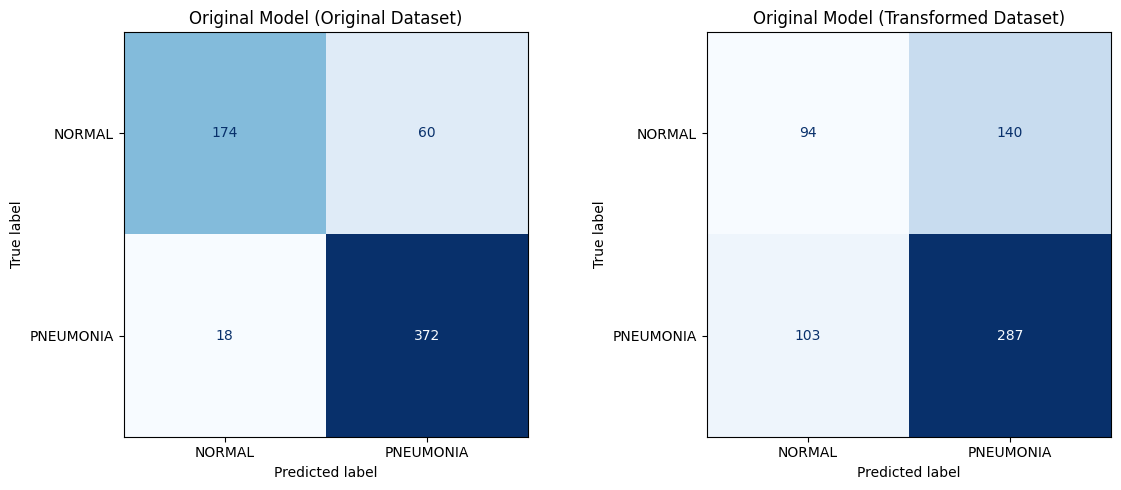

── Original Dataset ──
              precision    recall  f1-score   support

      NORMAL       0.91      0.74      0.82       234
   PNEUMONIA       0.86      0.95      0.91       390

    accuracy                           0.88       624
   macro avg       0.88      0.85      0.86       624
weighted avg       0.88      0.88      0.87       624

── Transformed Dataset ──
              precision    recall  f1-score   support

      NORMAL       0.48      0.40      0.44       234
   PNEUMONIA       0.67      0.74      0.70       390

    accuracy                           0.61       624
   macro avg       0.57      0.57      0.57       624
weighted avg       0.60      0.61      0.60       624



In [51]:
y_true_og = test_og["label"].values
y_pred_og = (original_model.predict(test_ds_og) >= og_threshold).astype(int).flatten()

y_true_trans = test_trans["label"].values
y_pred_trans = (original_model.predict(test_ds_trans) >= og_threshold).astype(int).flatten()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_true_og, y_pred_og, "Original Model (Original Dataset)"),
    (axes[1], y_true_trans, y_pred_trans, "Original Model (Transformed Dataset)"),
]:
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["NORMAL", "PNEUMONIA"])
    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.savefig("CM/original_model.png", dpi=150, bbox_inches="tight")
plt.show()

print("── Original Dataset ──")
print(classification_report(y_true_og, y_pred_og, target_names=["NORMAL", "PNEUMONIA"]))

print("── Transformed Dataset ──")
print(classification_report(y_true_trans, y_pred_trans, target_names=["NORMAL", "PNEUMONIA"]))

## Testing Transformed Model

Here I am testing the performance of the model trained on the transformed xray dataset. I evaluate it on the test sets from the original and transformed datasets to see difference in performance

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


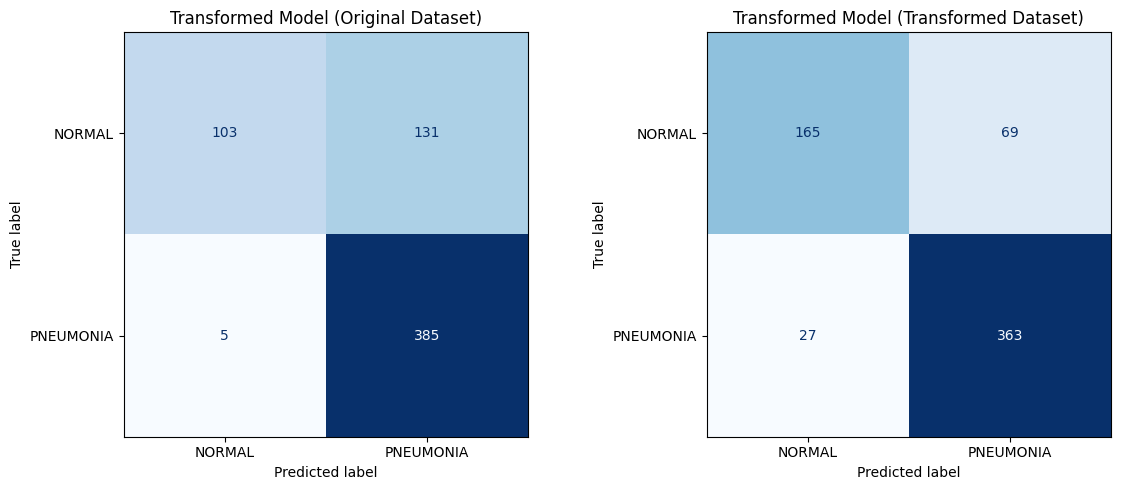

── Original Dataset ──
              precision    recall  f1-score   support

      NORMAL       0.95      0.44      0.60       234
   PNEUMONIA       0.75      0.99      0.85       390

    accuracy                           0.78       624
   macro avg       0.85      0.71      0.73       624
weighted avg       0.82      0.78      0.76       624

── Transformed Dataset ──
              precision    recall  f1-score   support

      NORMAL       0.86      0.71      0.77       234
   PNEUMONIA       0.84      0.93      0.88       390

    accuracy                           0.85       624
   macro avg       0.85      0.82      0.83       624
weighted avg       0.85      0.85      0.84       624



In [52]:
y_true_og = test_og["label"].values
y_pred_og = (transformed_model.predict(test_ds_og) >= tr_threshold).astype(int).flatten()

y_true_trans = test_trans["label"].values
y_pred_trans = (transformed_model.predict(test_ds_trans) >= tr_threshold).astype(int).flatten()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_true_og, y_pred_og, "Transformed Model (Original Dataset)"),
    (axes[1], y_true_trans, y_pred_trans, "Transformed Model (Transformed Dataset)"),
]:
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["NORMAL", "PNEUMONIA"])
    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.savefig("CM/transformed_model.png", dpi=150, bbox_inches="tight")
plt.show()

print("── Original Dataset ──")
print(classification_report(y_true_og, y_pred_og, target_names=["NORMAL", "PNEUMONIA"]))

print("── Transformed Dataset ──")
print(classification_report(y_true_trans, y_pred_trans, target_names=["NORMAL", "PNEUMONIA"]))

## Testing Combined Model

Finally, looking at the previous performances, I wanted to train a model on a combined dataset; the idea was to look at a model which looked at both 'types' of imaging. I assumed this would make a more robust model which learned both protocol images and can therefore produce better results when processing images regardless of the protocol used to obtain it. The purpose of this was to kind of show that a quick solution to such a dependence on radiology protocol could be to train on a combined dataset with images gained from different protocols. I trained the model on a mix of both original and transformed xrays, while making sure that images from the same patient are NOT included (can't have an original and transformed image of the same patient). This is because this is not a realistic case so it won't be something we could replicate in the field when obtaining data as it is not common, and i would go as far as that it never happens, for 2 xrays of the same patient to exist with the same results from different protocols; radiologists do not advise constant imaging back to back because of radiation exposure, and even if 2 xrays of different protocol are taken of the same patient, they tend to have a non-negligible time span inbetween so we can't assume the internal structure of the patient would be exactly the same assuming they are unhealthy while getting a scan or have gotten healthy. 

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step


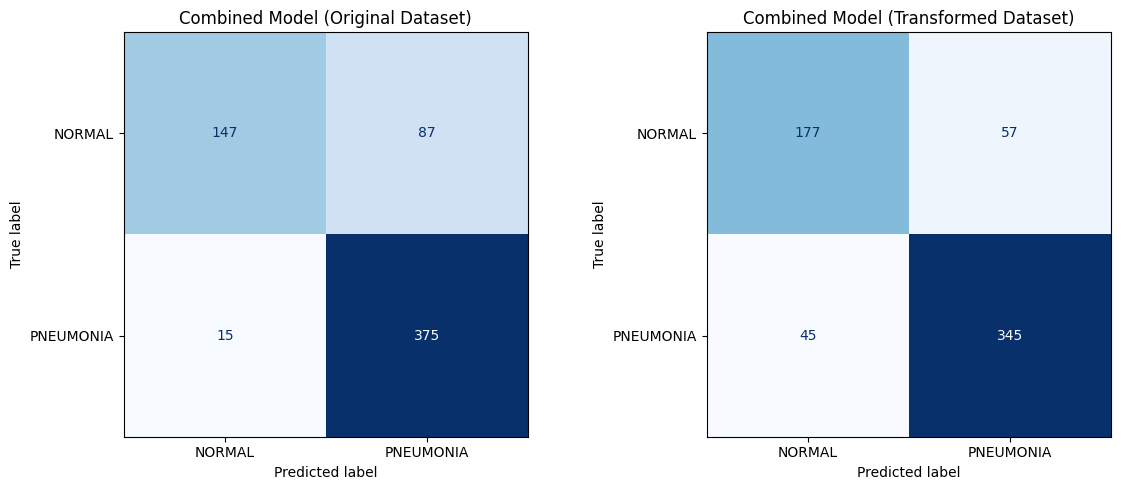

── Original Dataset ──
              precision    recall  f1-score   support

      NORMAL       0.91      0.63      0.74       234
   PNEUMONIA       0.81      0.96      0.88       390

    accuracy                           0.84       624
   macro avg       0.86      0.79      0.81       624
weighted avg       0.85      0.84      0.83       624

── Transformed Dataset ──
              precision    recall  f1-score   support

      NORMAL       0.80      0.76      0.78       234
   PNEUMONIA       0.86      0.88      0.87       390

    accuracy                           0.84       624
   macro avg       0.83      0.82      0.82       624
weighted avg       0.84      0.84      0.84       624



In [53]:
y_true_og = test_og["label"].values
y_pred_og = (combined_model.predict(test_ds_og) >= comb_threshold).astype(int).flatten()

y_true_trans = test_trans["label"].values
y_pred_trans = (combined_model.predict(test_ds_trans) >= comb_threshold).astype(int).flatten()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_true_og, y_pred_og, "Combined Model (Original Dataset)"),
    (axes[1], y_true_trans, y_pred_trans, "Combined Model (Transformed Dataset)"),
]:
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["NORMAL", "PNEUMONIA"])
    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.savefig("CM/combined_model.png", dpi=150, bbox_inches="tight")
plt.show()

print("── Original Dataset ──")
print(classification_report(y_true_og, y_pred_og, target_names=["NORMAL", "PNEUMONIA"]))

print("── Transformed Dataset ──")
print(classification_report(y_true_trans, y_pred_trans, target_names=["NORMAL", "PNEUMONIA"]))

## Additional Analysis

Getting all 3 models' results on both datasets; getting just pure probabilities for analysis on why the models perform different on each dataset.

In [47]:
og_probs_og = original_model.predict(test_ds_og).flatten()
og_probs_trans  = original_model.predict(test_ds_trans).flatten()
tr_probs_og = transformed_model.predict(test_ds_og).flatten()
tr_probs_trans  = transformed_model.predict(test_ds_trans).flatten()
cb_probs_og = combined_model.predict(test_ds_og).flatten()
cb_probs_trans  = combined_model.predict(test_ds_trans).flatten()

y_true_og = test_og["label"].values
y_true_trans = test_trans["label"].values

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


Visualising the distribution of predicted probabilities split by true class for each model-dataset combo. This shows if poor performance is due to model collapse (both classes predicted near 1.0 with no separation) or miscalibration (classes are separable but the threshold is cutting in the wrong place). 

If a model collapses on the dataset it was NOT trained on, that would imply that the model learned protocol-specific visual features (based on the resolution, noise, etc) rather than the underlying anatomy which would identify whether a patient is healthy or not. So when the protocol changes, the model would just probably resort to predicting the majority class. 

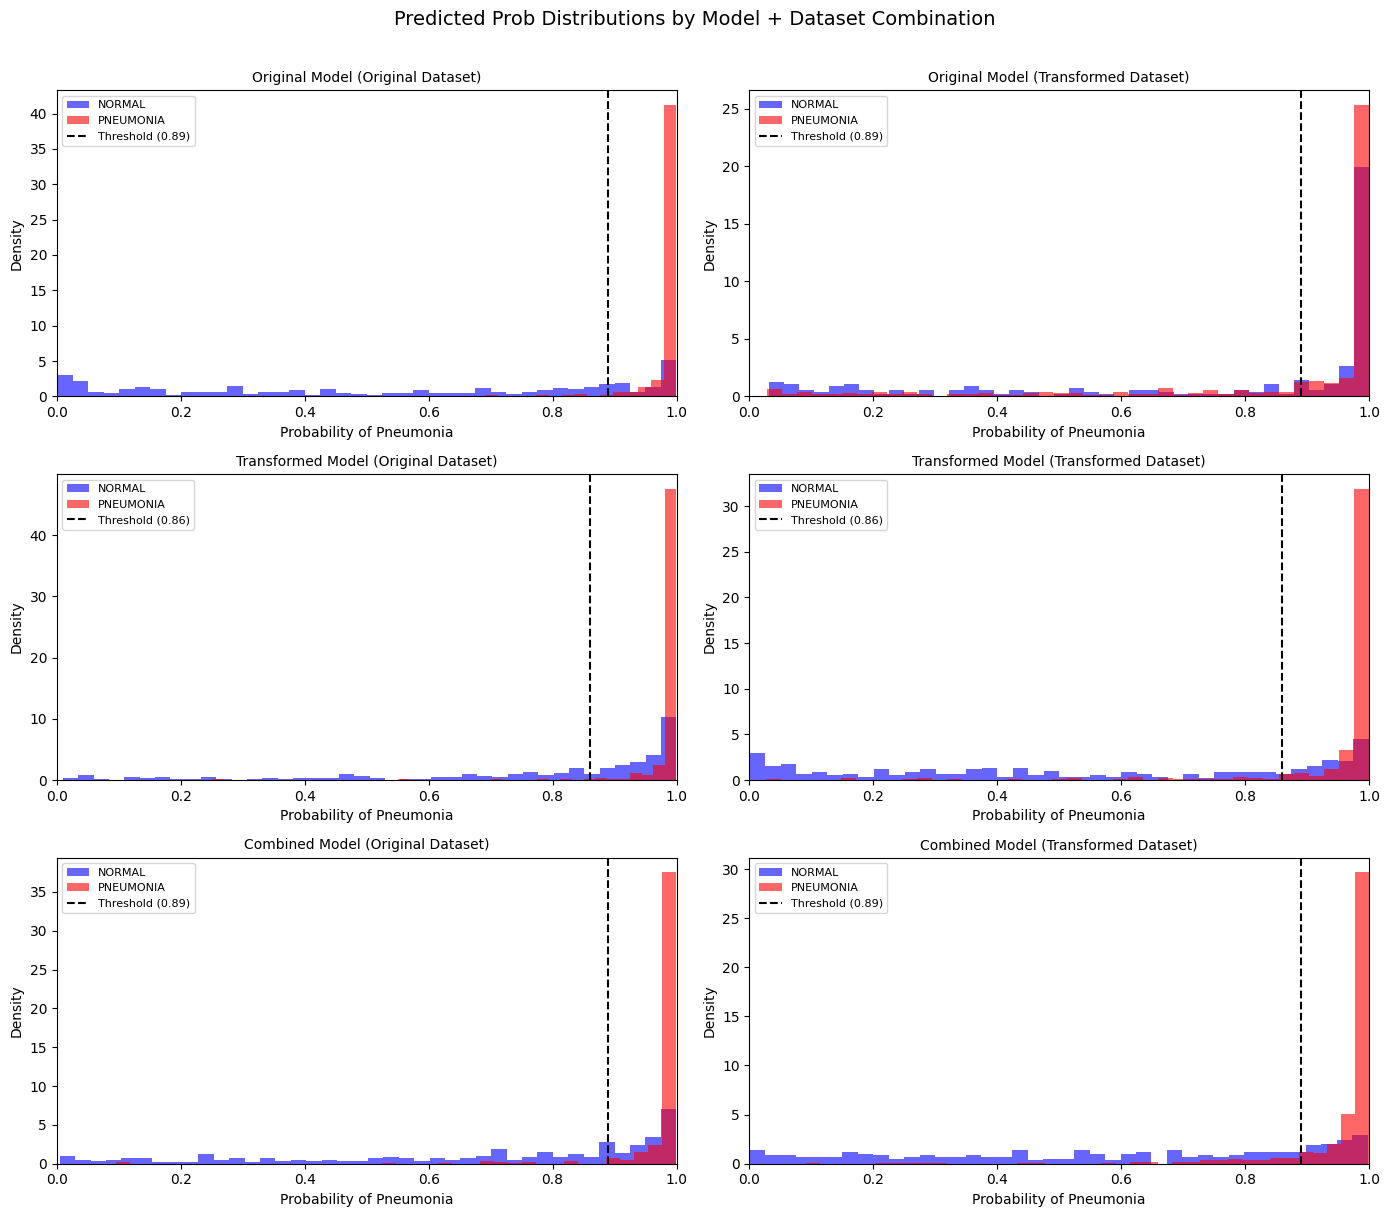

In [48]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle("Predicted Prob Distributions by Model + Dataset Combination", fontsize=14, y=1.01)

#made it a list so it's easier to process each in a loop
combos = [
    (og_probs_og, y_true_og, og_threshold, "Original Model (Original Dataset)", axes[0, 0]),
    (og_probs_trans, y_true_trans, og_threshold,"Original Model (Transformed Dataset)", axes[0, 1]),
    (tr_probs_og, y_true_og, tr_threshold, "Transformed Model (Original Dataset)", axes[1, 0]),
    (tr_probs_trans, y_true_trans, tr_threshold, "Transformed Model (Transformed Dataset)", axes[1, 1]),
    (cb_probs_og, y_true_og, comb_threshold,"Combined Model (Original Dataset)", axes[2, 0]),
    (cb_probs_trans, y_true_trans, comb_threshold,"Combined Model (Transformed Dataset)", axes[2, 1]),
]

for probs, y_true, threshold, title, ax in combos:
    ax.hist(probs[y_true == 0], bins=40, alpha=0.6, label="NORMAL",    color='blue', density=True)
    ax.hist(probs[y_true == 1], bins=40, alpha=0.6, label="PNEUMONIA", color="red", density=True)
    ax.axvline(threshold, color="black", linestyle="--", linewidth=1.5, label=f"Threshold ({threshold:.2f})")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Probability of Pneumonia")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig("analysis/probability_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

ROC curves show class separability independently of threshold choice which allows comparison across models that use different thresholds. The point of plotting these together is a large AUC drop moving from the dataset being trained on to the other dataset shows the model has learned protocol-specific features rather than general features indicating disease presence which shows reliance on the underlying protocol.

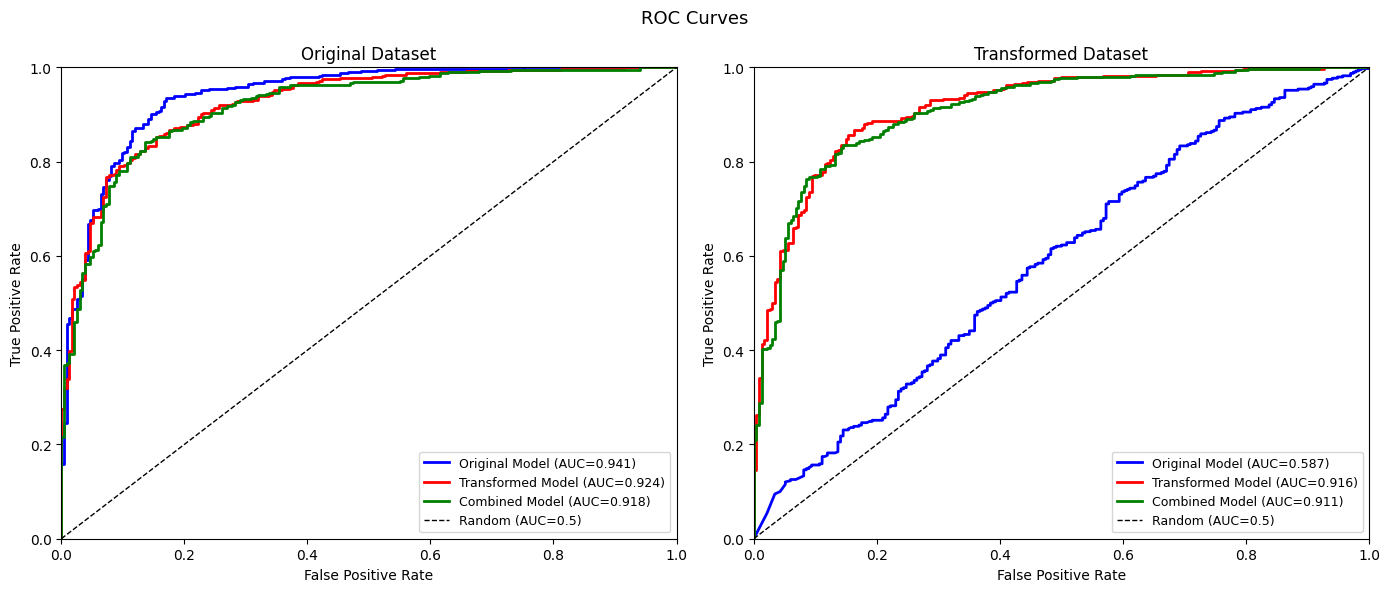

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

model_combos = {
    "Original Model": [(og_probs_og, y_true_og, "vs Original"), (og_probs_trans, y_true_trans, "vs Transformed")],
    "Transformed Model": [(tr_probs_og, y_true_og,"vs Original"), (tr_probs_trans, y_true_trans, "vs Transformed")],
    "Combined Model": [(cb_probs_og,y_true_og,"vs Original"), (cb_probs_trans, y_true_trans, "vs Transformed")],
}

colors = {
    "Original Model": "blue",   
    "Transformed Model": "red",   
    "Combined Model": "green",   
}

for model_name, combos in model_combos.items():
    for i, (probs, y_true, label) in enumerate(combos):
        fpr, tpr, _ = roc_curve(y_true, probs)
        auc_score = roc_auc_score(y_true, probs)
        color = colors[model_name]
        ax = axes[i]
        ax.plot(fpr, tpr, color=color, linewidth=2,
                label=f"{model_name} (AUC={auc_score:.3f})")

for ax, title in zip(axes, ["Original Dataset", "Transformed Dataset"]):
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC=0.5)")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

fig.suptitle("ROC Curves", fontsize=13)
plt.tight_layout()
plt.savefig("analysis/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

Summarising per class per model-dataset combination together

In [50]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_map = {
    "Original Model": (og_probs_og,og_probs_trans, og_threshold),
    "Transformed Model": (tr_probs_og, tr_probs_trans, tr_threshold),
    "Combined Model": (cb_probs_og, cb_probs_trans, comb_threshold),
}

rows = []
for model_name, (probs_og, probs_trans, threshold) in thresholds_map.items():
    for dataset_name, probs, y_true in [("Original", probs_og, y_true_og), ("Transformed", probs_trans, y_true_trans)]:
        y_pred = (probs >= threshold).astype(int)
        auc = roc_auc_score(y_true, probs)
        rows.append({
            "Model": model_name,
            "Test Dataset": dataset_name,
            "NORMAL Precision": precision_score(y_true, y_pred, pos_label=0),
            "NORMAL Recall": recall_score(y_true, y_pred, pos_label=0),
            "NORMAL F1": f1_score(y_true, y_pred, pos_label=0),
            "PNEUMONIA Recall": recall_score(y_true, y_pred, pos_label=1),
            "PNEUMONIA F1": f1_score(y_true, y_pred, pos_label=1),
            "AUC": auc,
        })

#formatting
summary_df = pd.DataFrame(rows)
summary_df = summary_df.round(3)


print(summary_df.to_string(index=False))

            Model Test Dataset  NORMAL Precision  NORMAL Recall  NORMAL F1  PNEUMONIA Recall  PNEUMONIA F1   AUC
   Original Model     Original             0.906          0.744      0.817             0.954         0.905 0.941
   Original Model  Transformed             0.477          0.402      0.436             0.736         0.703 0.587
Transformed Model     Original             0.954          0.440      0.602             0.987         0.850 0.924
Transformed Model  Transformed             0.859          0.705      0.775             0.931         0.883 0.916
   Combined Model     Original             0.907          0.628      0.742             0.962         0.880 0.918
   Combined Model  Transformed             0.797          0.756      0.776             0.885         0.871 0.911
